# Main Imports

In [1]:
import os
import torch
import mlflow
import pandas as pd
from mlflow import MlflowClient
import matplotlib.pyplot as plt
from torchvision import transforms

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%config InlineBackend.figure_format = 'svg'

In [3]:
os.environ["MLFLOW_TRACKING_URI"] = "https://gitlab.ost.ch/api/v4/projects/15439/ml/mlflow/"
os.environ["MLFLOW_TRACKING_TOKEN"] = ""

In [4]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cuda')

In [5]:
print("Device Info")
print("Selected device:", device)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("GPU count:", torch.cuda.device_count())
    print("Current GPU index:", torch.cuda.current_device())
    print("GPU name:", torch.cuda.get_device_name(torch.cuda.current_device()))
    print("GPU capability:", torch.cuda.get_device_capability())
else:
    print("Running on CPU")

Device Info
Selected device: cuda
CUDA available: True
CUDA version: 12.2
GPU count: 8
Current GPU index: 0
GPU name: Tesla P100-SXM2-16GB
GPU capability: (6, 0)


# Dataset Loader

In [6]:
from torch.utils.data import DataLoader
from social_media_overlay.ext.gebhardt.dataset.CocoCaptions import CocoCaptions

In [7]:
dataset_input_size = 1024  # 1024
dataset_crop_size = 1024  # 1024
dataset_batch_size = 2
dataset_shuffle = False


data_transforms = transforms.Compose([
    transforms.Resize(dataset_input_size),
    transforms.CenterCrop(dataset_crop_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # this will be [-1,1]
])

dataset_coco = CocoCaptions("../data/coco", "val", data_transforms)
data_loader = DataLoader(
    dataset_coco,
    batch_size=dataset_batch_size,
    shuffle=dataset_shuffle,
    #num_workers=0
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

COCO Dataset Debug Info
Root: ../data/coco
Split: val
Annotation file: ../data/coco/annotations/captions_val2017.json
Image directory: ../data/coco/val2017
Root exists ✓
Annotation file exists ✓
Image directory exists ✓
Images found in directory: 5000
Loading annotation metadata...
Entries in image_list: 5000
Dataset initialization finished.


In [8]:
print("Dataset length:", len(dataset_coco))
print("Batch size:", data_loader.batch_size)
print("Shuffle:", dataset_shuffle)
print("Num workers:", data_loader.num_workers)
print("Number of batches per epoch:", len(data_loader))

Dataset length: 5000
Batch size: 2
Shuffle: False
Num workers: 4
Number of batches per epoch: 2500


In [9]:
dataset_coco[0]

(tensor([[[-0.3569, -0.3412, -0.3490,  ...,  0.9451,  0.7647,  0.6471],
          [-0.3804, -0.3647, -0.3647,  ...,  0.9451,  0.7647,  0.6471],
          [-0.4353, -0.4118, -0.4118,  ...,  0.9451,  0.7725,  0.6549],
          ...,
          [-0.4902, -0.4588, -0.3569,  ..., -0.1216, -0.0980, -0.0824],
          [-0.5608, -0.5765, -0.4745,  ..., -0.2392, -0.1686, -0.1137],
          [-0.5922, -0.6314, -0.5294,  ..., -0.2863, -0.2000, -0.1294]],
 
         [[-0.2941, -0.2784, -0.2863,  ...,  0.9137,  0.7333,  0.6157],
          [-0.3176, -0.3020, -0.3098,  ...,  0.9137,  0.7333,  0.6157],
          [-0.3804, -0.3569, -0.3569,  ...,  0.9137,  0.7412,  0.6235],
          ...,
          [-0.4745, -0.4431, -0.3255,  ..., -0.0431, -0.0118,  0.0039],
          [-0.5451, -0.5451, -0.4431,  ..., -0.1451, -0.0745, -0.0196],
          [-0.5765, -0.5922, -0.4902,  ..., -0.1922, -0.1059, -0.0353]],
 
         [[-0.1922, -0.1765, -0.1843,  ...,  0.9216,  0.7412,  0.6235],
          [-0.2235, -0.2078,

# Load Munit Generator

In [12]:
from social_media_overlay.ext.imaginaire.config import Config
from social_media_overlay.ext.imaginaire.generators.munit import Generator
from social_media_overlay.ext.gebhardt.utils import get_relevant_states

In [13]:
cfg = Config("../src/social_media_overlay/ext/imaginaire/imagenet2imagenet.yaml")
gen = Generator(cfg.gen, cfg.data)

state_dict = torch.load("../data/gebhardt/models/imaginaire_munit_200000_s5.pt")

gen_sate_dict = get_relevant_states(state_dict['net_G'])
gen.load_state_dict(gen_sate_dict)
gen = gen.to(device)

for p in gen.parameters():
    p.requires_grad = False

In [20]:
x = torch.randn(1, 3, 256, 256, device=device)

with torch.no_grad():
    content_a, style_a = gen.autoencoder_a.encode(x)
    out = gen.autoencoder_a.decode(content_a, style_a)

print("content shape:", tuple(content_a.shape))
print("style shape:", tuple(style_a.shape))
print("decoder A output shape:", tuple(out.shape))

content shape: (1, 256, 32, 32)
style shape: (1, 8, 1, 1)
decoder A output shape: (1, 3, 256, 256)


## Get Style Dimensions

In [12]:
gen.eval()

# dummy input (ImageNet size typically 256x256)
x = torch.randn(1, 3, 256, 256).to(device)

with torch.no_grad():
    content_a, style_a = gen.autoencoder_a.encode(x)

print("MUNIT Latent Space Info")
print("Content shape:", content_a.shape)
print("Style shape:", style_a.shape)

# extract style dimension
style_dim = style_a.shape[1]
print("Style dimension:", style_dim)

MUNIT Latent Space Info
Content shape: torch.Size([1, 256, 32, 32])
Style shape: torch.Size([1, 8, 1, 1])
Style dimension: 8


# Load Regressor

In [13]:
from social_media_overlay.models.regressor import EmotionRegressor

In [14]:
path_to_regressor_model = "../data/gebhardt/models/va_pred_all"
regressor = EmotionRegressor(path_to_regressor_model, average=True)
regressor.to(device)

for p in regressor.model.parameters():
    p.requires_grad = False

In [15]:
print("regressor:", regressor)
print("type(regressor):", type(regressor))

regressor: <social_media_overlay.models.regressor.EmotionRegressor object at 0x7f0bde99ae60>
type(regressor): <class 'social_media_overlay.models.regressor.EmotionRegressor'>


# Objective
(R(G(T(s,a),c))-(R(G(s,c))+a))^2
is equal to MSE of regressor value of transformed image by alpha minus the untransformed generated image regressor value plus alpha.

## Replace G(s,c) with source image
(R(G(T(s,a),c))-(R(x_i)+a))^2

In [19]:
from social_media_overlay.models.latent_style import LatentStyleModel
from torch.optim.adam import Adam

In [20]:
# ../data/models/singleDirectionTransformer_lr_ganalyze_20260308_200728.pt
saved_path = "../data/models/checkpoints-1/style-b2-ddp-final.pt"

In [21]:
model = LatentStyleModel(
    regressor=regressor,
    generator=gen,
    style_dim=style_dim,
    a_min=-0.5,
    a_max=0
).to(device)

if saved_path:
    checkpoint = torch.load(saved_path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])

In [22]:
optimizer = Adam(model.parameters(), lr=0.0002) # lr from ganalyze
if saved_path:
    checkpoint = torch.load(saved_path, map_location=device)
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

ValueError: loaded state dict contains a parameter group that doesn't match the size of optimizer's group

# Training

In [24]:
import json
import time
from pathlib import Path
import matplotlib.pyplot as plt
from itertools import cycle
from torch.nn import MSELoss

In [25]:
def train(
    dataloader,
    model,
    loss_fn,
    optimizer,
    device,
    save_state,
    save_path,
    save_name,
):
    size = len(dataloader.dataset)

    model.train()

    train_losses = []

    for batch, (X, y) in enumerate(dataloader):
        X = X.to(device)
        batch_size = X.size(0)

        optimizer.zero_grad()
        alphas = model.sample_alpha(batch_size).to(device)
        with torch.no_grad():
            original_scores = model.valence_score(X)

        transformed_scores = model(X, alphas)
        target_score = original_scores + alphas
        loss = loss_fn(transformed_scores, target_score)

        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        if batch % 100 == 0:
            current = (batch + 1) * len(X)
            print(f"#loss: {loss.item():>7f}  [{current:>5d}/{size:>5d}]")
            mlflow.log_metric("train/loss", loss.item(), step=batch)

            if torch.cuda.is_available():
                mlflow.log_metric(
                    "system/gpu_memory_allocated_gb",
                    torch.cuda.memory_allocated() / 1024**3, step=batch
                )
                mlflow.log_metric(
                    "system/gpu_memory_reserved_gb",
                    torch.cuda.memory_reserved() / 1024**3, step=batch
                )
                print(
                    "allocated:",
                    torch.cuda.memory_allocated() / 1024**3, "GB"
                )
                print(
                    "reserved :",
                    torch.cuda.memory_reserved() / 1024**3, "GB"
                )
            if save_state:
                torch.save(
                    {
                        "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict()
                    },
                    f"{save_path}/{save_name}-{batch}.pt"
                )
    return train_losses

In [26]:
import gc
import time
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
experiment_name = f"style-b2-{timestamp}-e2"
pt_path = "../data/models"

client = MlflowClient()

try:
    experiment_id = client.create_experiment(
        name=experiment_name,
        tags={"project": "style-transform"},
    )
except Exception:
    experiment = client.get_experiment_by_name(experiment_name)
    experiment_id = experiment.experiment_id

loss_fn = MSELoss()
epochs = 1
steps_per_epoch = len(data_loader)
total_planned_steps = epochs * steps_per_epoch

run_start_time = time.perf_counter()
run_start_datetime = datetime.utcnow().isoformat()

completed_epochs = 0
completed_steps = 0
interrupted = False
all_losses = []

with mlflow.start_run(experiment_id=experiment_id):
    try:
        # Params
        mlflow.log_param("batch_size", getattr(data_loader, "batch_size", None))
        mlflow.log_param("optimizer", type(optimizer).__name__)
        mlflow.log_param("loss_fn", type(loss_fn).__name__)
        mlflow.log_param("epochs", epochs)
        mlflow.log_param("steps_per_epoch", steps_per_epoch)
        mlflow.log_param("total_planned_steps", total_planned_steps)
        mlflow.log_param("amp", True)
        mlflow.log_param("model_class", type(model).__name__)
        mlflow.log_param("device", str(device))

        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(
            p.numel() for p in model.parameters() if p.requires_grad
        )
        mlflow.log_param("total_parameters", total_params)
        mlflow.log_param("trainable_parameters", trainable_params)

        # Tags
        mlflow.set_tag("project", "style-transform")
        mlflow.set_tag("run_started_utc", run_start_datetime)

        global_step = 0

        for epoch_idx in range(epochs):
            epoch_num = epoch_idx + 1
            epoch_start_time = time.perf_counter()

            print(f"Epoch {epoch_num}\n-------------------------------")

            epoch_losses = train(
                dataloader=data_loader,
                model=model,
                loss_fn=loss_fn,
                optimizer=optimizer,
                device=device,
                save_state=True,
                save_path=pt_path,
                save_name=experiment_name,
            )

            # Make sure it's a list/iterable of numbers
            if epoch_losses is None:
                epoch_losses = []

            all_losses.extend(epoch_losses)

            # Log batch losses
            for batch_idx, loss_value in enumerate(epoch_losses, start=1):
                global_step += 1
                mlflow.log_metric("train_loss_step", float(loss_value), step=global_step)

            # Epoch summary metrics
            epoch_duration_sec = time.perf_counter() - epoch_start_time
            completed_epochs += 1
            completed_steps += len(epoch_losses)

            if len(epoch_losses) > 0:
                epoch_loss_mean = sum(epoch_losses) / len(epoch_losses)
                epoch_loss_min = min(epoch_losses)
                epoch_loss_max = max(epoch_losses)

                mlflow.log_metric("train_loss_epoch_mean", float(epoch_loss_mean), step=epoch_num)
                mlflow.log_metric("train_loss_epoch_min", float(epoch_loss_min), step=epoch_num)
                mlflow.log_metric("train_loss_epoch_max", float(epoch_loss_max), step=epoch_num)

            mlflow.log_metric("epoch_duration_sec", epoch_duration_sec, step=epoch_num)
            mlflow.log_metric("completed_epochs", completed_epochs, step=epoch_num)
            mlflow.log_metric("completed_steps", completed_steps, step=epoch_num)

        print("Done!")

    except KeyboardInterrupt:
        interrupted = True
        print("\nTraining interrupted.")

    finally:
        total_duration_sec = time.perf_counter() - run_start_time

        mlflow.log_metric("total_duration_sec", total_duration_sec)
        mlflow.log_metric("completed_epochs_final", completed_epochs)
        mlflow.log_metric("completed_steps_final", completed_steps)

        if len(all_losses) > 0:
            mlflow.log_metric("train_loss_overall_mean", float(sum(all_losses) / len(all_losses)))
            mlflow.log_metric("train_loss_overall_min", float(min(all_losses)))
            mlflow.log_metric("train_loss_overall_max", float(max(all_losses)))
            mlflow.log_metric("last_train_loss", float(all_losses[-1]))

        if total_duration_sec > 0:
            mlflow.log_metric("steps_per_sec", completed_steps / total_duration_sec)
            mlflow.log_metric("epochs_per_sec", completed_epochs / total_duration_sec)

        mlflow.set_tag("status", "interrupted" if interrupted else "finished")

        if torch.cuda.is_available():
            mlflow.log_metric("cuda_memory_allocated_mb", torch.cuda.memory_allocated() / 1024**2)
            mlflow.log_metric("cuda_memory_reserved_mb", torch.cuda.memory_reserved() / 1024**2)

        print("Cleaning GPU memory...")
        torch.cuda.empty_cache()
        gc.collect()

Epoch 1
-------------------------------
#loss: 0.068744  [    2/ 5000]
allocated: 1.0422887802124023 GB
reserved : 14.12890625 GB
#loss: 0.079818  [  202/ 5000]
allocated: 1.043684959411621 GB
reserved : 14.12890625 GB
#loss: 0.086733  [  402/ 5000]
allocated: 1.043684959411621 GB
reserved : 14.12890625 GB
#loss: 0.009648  [  602/ 5000]
allocated: 1.0427160263061523 GB
reserved : 14.12890625 GB
#loss: 0.003396  [  802/ 5000]
allocated: 1.043318748474121 GB
reserved : 14.12890625 GB
#loss: 0.098203  [ 1002/ 5000]
allocated: 1.0425939559936523 GB
reserved : 14.12890625 GB
#loss: 0.003161  [ 1202/ 5000]
allocated: 1.0431432723999023 GB
reserved : 14.12890625 GB
#loss: 0.165841  [ 1402/ 5000]
allocated: 1.0433263778686523 GB
reserved : 14.12890625 GB
#loss: 0.041872  [ 1602/ 5000]
allocated: 1.0433263778686523 GB
reserved : 14.12890625 GB
#loss: 0.058604  [ 1802/ 5000]
allocated: 1.0425939559936523 GB
reserved : 14.12890625 GB
#loss: 0.062861  [ 2002/ 5000]
allocated: 1.0434484481811523 GB

In [27]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict()
    },
    f"{pt_path}/{experiment_name}-e2.pt"
)

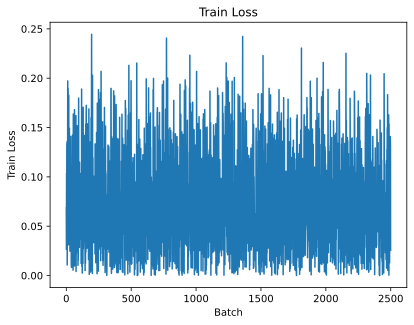

In [28]:
plt.plot(all_losses)
plt.xlabel("Batch")
plt.ylabel("Train Loss")
plt.title("Train Loss")
plt.savefig(f"{experiment_name}_loss.svg", format="svg")
plt.show()

In [23]:
# plus
model._parameters

OrderedDict([('w',
              Parameter containing:
              tensor([[-0.2178,  1.2543, -2.1275, -0.5149, -0.4547,  0.2015, -0.9587,  0.0924]],
                     device='cuda:0', requires_grad=True))])

In [23]:
from social_media_overlay.utils import get_first_n_images
from social_media_overlay.ext.gebhardt.utils import denorm

In [24]:
alphas = [0.0, 0.1, 0.25, 0.5, 1.0]

X8 = get_first_n_images(data_loader, n=8)
X8_device = X8.to(device)

model.eval()
model.regressor.eval()
model.generator.eval()

outputs = []
scores_list = []

with torch.no_grad():
    original_scores = model.regressor.predict(X8_device).detach().cpu()

    for alpha in alphas:
        alpha_tensor = torch.full(
            (X8_device.size(0), 1),
            alpha,
            device=device
        )

        out = model.generate_transformed_images(
            X=X8_device,
            alphas=alpha_tensor
        )
        outputs.append(out.detach().cpu())

        scores = model.regressor.predict(out).detach().cpu()
        scores_list.append(scores)

# identity reference = alpha 0.0
identity_idx = alphas.index(0.0)
identity_scores = scores_list[identity_idx]

rows = X8.size(0)
cols = len(alphas) + 1

fig, axes = plt.subplots(rows, cols, figsize=(3.8 * cols, 3.6 * rows))

if rows == 1:
    axes = axes[None, :]

for r in range(rows):
    # original image
    ax = axes[r, 0]
    img = denorm(X8[r]).permute(1, 2, 0).cpu().numpy()

    v_orig = original_scores[r, 0].item()
    a_orig = original_scores[r, 1].item()

    v_id = identity_scores[r, 0].item()
    a_id = identity_scores[r, 1].item()

    dv_orig_id = v_orig - v_id
    da_orig_id = a_orig - a_id

    ax.imshow(img)
    ax.set_title(
        f"original\nv={v_orig:.3f}, a={a_orig:.3f}\nΔid v={dv_orig_id:+.3f}, a={da_orig_id:+.3f}",
        fontsize=10
    )
    ax.axis("off")

    # transformed images
    for c, alpha in enumerate(alphas, start=1):
        ax = axes[r, c]
        img = denorm(outputs[c - 1][r]).permute(1, 2, 0).cpu().numpy()

        v = scores_list[c - 1][r, 0].item()
        a = scores_list[c - 1][r, 1].item()

        dv = v - v_id
        da = a - a_id

        label = "identity" if alpha == 0.0 else f"α={alpha}"

        ax.imshow(img)
        ax.set_title(
            f"{label}\nv={v:.3f}, a={a:.3f}\nΔv={dv:+.3f}, Δa={da:+.3f}",
            fontsize=10
        )
        ax.axis("off")

plt.tight_layout()
plt.show()

Loaded 3120 loss values


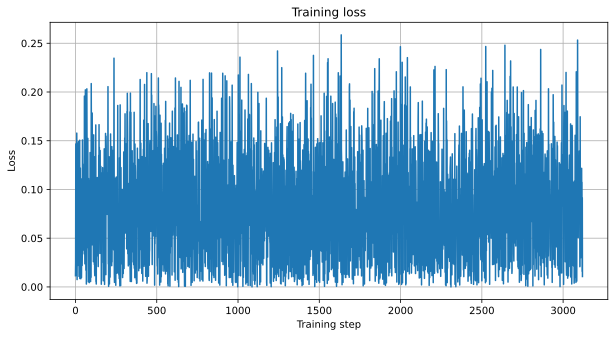

In [10]:
checkpoint = torch.load(saved_path, map_location=device)

loss_history = checkpoint["loss_history"]

print(f"Loaded {len(loss_history)} loss values")

plt.figure(figsize=(10,5))
plt.plot(loss_history)
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Training loss")
plt.grid(True)
plt.show()